## Q3)

In [ ]:
# 1)

import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

def random_ortho(dim):
        W = torch.randn(dim, dim)
        q, r = torch.linalg.qr(W)
        return q

class CouplingLayer(nn.Module):
    def __init__(self, input_size, hidden_size, mask):
        super().__init__()
        self.register_buffer('mask', mask)
        self.nested_net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 2*input_size)
        )

    def forward(self, x):
        m = self.mask
        x_m = x*m
        h = self.nested_net(x_m)
        t, s = torch.chunk(h, 2, dim = -1)
        s = 0.1 * torch.tanh(s)
        scale = torch.exp(s)
        y = x_m + (1 - m) * (x * scale + t)
        log_det = torch.sum((1-m)*s, dim = -1)
        return y, log_det
        
    
    def inverse(self, y):
        m = self.mask
        y_m = y * m
        h = self.nested_net(y_m)
        t,s = torch.chunk(h, 2, dim = -1)
        s = 0.1 * torch.tanh(s)
        scale = torch.exp(s)
        x = y_m + (1 - m) * ((y - t) / scale)
        log_det = -torch.sum((1-m) * s, dim = -1)
        return x, log_det
        
class realNVP(nn.Module):
    def __init__(self, input_size, hidden_size, blocks):
        super().__init__()
        masks = []
        for i in range(blocks):
            mask = (torch.arange(input_size)%2 == (i%2)).float()
            masks.append(mask)
        self.blocks = blocks
        self.layers = nn.ModuleList([CouplingLayer(input_size, hidden_size, masks[i]) for i in range(blocks)])
        
    def forward(self, x):
        log_det_total = torch.zeros(x.size(0), device=x.device)
        y = x
        for i in self.layers:
            y, log_det = i(y)
            log_det_total += log_det
        return y, log_det_total
    
    def inverse(self, y):
        log_det_total = torch.zeros(y.size(0), device=y.device)
        x = y
        for i in reversed(self.layers):
            x, log_det = i.inverse(x)
            log_det_total += log_det
        return x, log_det_total
        
    def sample(self, num):
        z = torch.randn(num, self.layers[0].mask.numel(), device=device)
        x, _ = self.inverse(z)
        return x
    
#Training
def NLL_loss(z, log_det):
    log_pz = -0.5 * torch.sum(z**2, dim=1) - 0.5 * z.shape[1] * math.log(2 * math.pi)
    return -torch.mean(log_pz + log_det)
    
def train_inn(X, hidden_size, blocks, batch_size, lr, epochs, verbose = True):
    X = torch.tensor(X, dtype = torch.float32).to(device)
    
    dataloader = DataLoader(TensorDataset(X), 
                            size=batch_size, shuffle=True)
    
    model = realNVP(input_size = X.shape[1], hidden_size = hidden_size, blocks = blocks).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    for e in range(epochs):
        for (batch,) in dataloader:
            z, log_det = model(batch)
            loss = NLL_loss(z, log_det)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
        if verbose:
            print(f'Epoch [{e+1}/{epochs}], Loss: {loss.item():.4f}')
    return model

#Digits Data
digits = load_digits()
X = digits.data.astype(np.float32)
y = digits.target

X = (X-X.mean())/X.std()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

hidden_size = 512
blocks = 8
batch_size = 128
lr = 1e-3
epochs = 60

model = train_inn(X_train, hidden_size = hidden_size, blocks = blocks, batch_size = batch_size, lr = lr, epochs = epochs)


Epoch [1/60], Loss: 64.6087
Epoch [2/60], Loss: 53.7205
Epoch [3/60], Loss: 50.9004
Epoch [4/60], Loss: 46.7255
Epoch [5/60], Loss: 44.4884
Epoch [6/60], Loss: 43.8104
Epoch [7/60], Loss: 42.4347
Epoch [8/60], Loss: 41.4216
Epoch [9/60], Loss: 40.4217
Epoch [10/60], Loss: 39.5651
Epoch [11/60], Loss: 39.9634
Epoch [12/60], Loss: 38.9655
Epoch [13/60], Loss: 37.9566
Epoch [14/60], Loss: 37.7763
Epoch [15/60], Loss: 37.7360
Epoch [16/60], Loss: 37.5824
Epoch [17/60], Loss: 37.0073
Epoch [18/60], Loss: 37.4142
Epoch [19/60], Loss: 37.2663
Epoch [20/60], Loss: 36.5791
Epoch [21/60], Loss: 36.7576
Epoch [22/60], Loss: 36.1051
Epoch [23/60], Loss: 36.6312
Epoch [24/60], Loss: 36.4631
Epoch [25/60], Loss: 36.7001
Epoch [26/60], Loss: 36.3723
Epoch [27/60], Loss: 36.2429
Epoch [28/60], Loss: 35.9773
Epoch [29/60], Loss: 36.0632
Epoch [30/60], Loss: 35.8600
Epoch [31/60], Loss: 35.7654
Epoch [32/60], Loss: 35.8319
Epoch [33/60], Loss: 35.6470
Epoch [34/60], Loss: 35.6198
Epoch [35/60], Loss: 35

Overall Mean:  0.0302
Overall STD:  0.4029


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


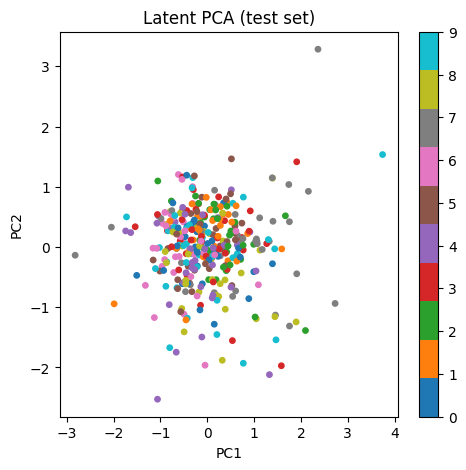

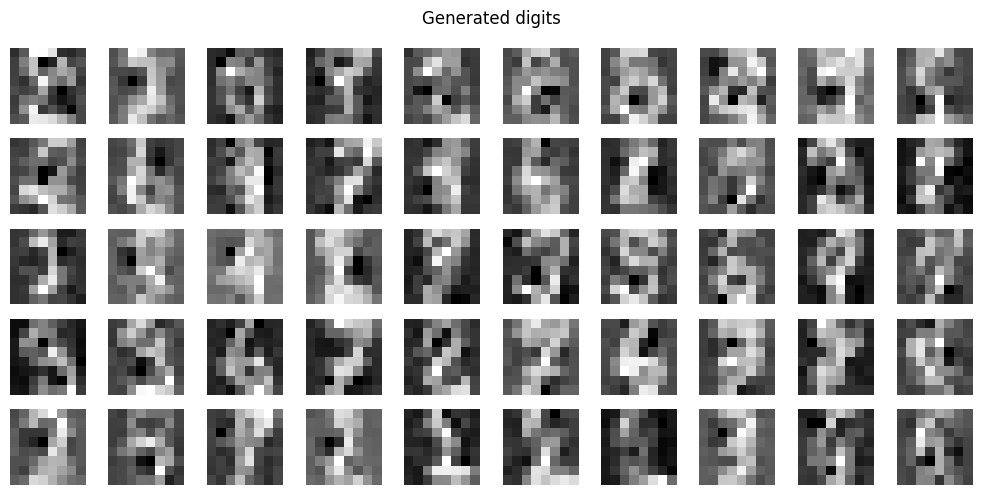

In [2]:
model.eval()
with torch.no_grad():
    X_test_torch = torch.tensor(X_test, dtype = torch.float32).to(device)
    z_test_torch, _ = model(X_test_torch)
    x_rec, _ = model.inverse(z_test_torch)
z_test = z_test_torch.cpu().numpy()    
means = z_test.mean(axis = 0)
stds = z_test.std(axis = 0)
print("Overall Mean: ", np.round(z_test.mean(), 4 ))
print("Overall STD: ", np.round(z_test.std(),4))

#2D projections
pca = PCA(n_components = 2, random_state = seed)
z_pca = pca.fit_transform(z_test)

tsne = TSNE(n_components = 2, random_state = seed, init = 'pca', learning_rate = 'auto', perplexity = 30)
z_tsne = tsne.fit_transform(z_test)
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
scatter = plt.scatter(z_pca[:,0], z_pca[:,1], c = y_test, cmap = 'tab10', s = 15)
plt.title('Latent PCA (test set)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter, ticks = range(10))



n_samples = 1000
with torch.no_grad():
    samples = model.sample(n_samples).cpu().numpy()

fig, axes = plt.subplots(5,10, figsize = (10,5))

for i, a in enumerate(axes.flatten()):
    a.imshow(samples[i].reshape(8,8), cmap = 'gray')
    a.axis('off')

plt.suptitle('Generated digits')
plt.tight_layout()
plt.show()

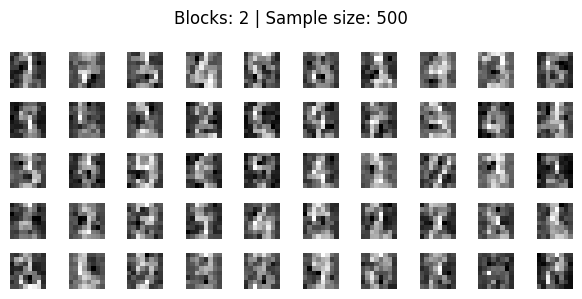

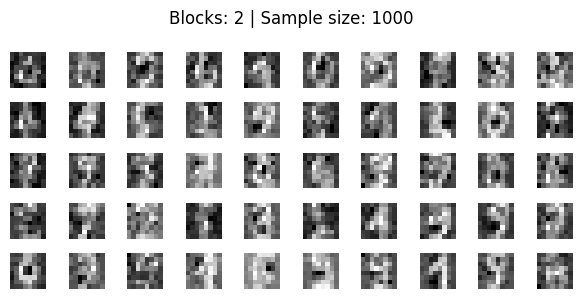

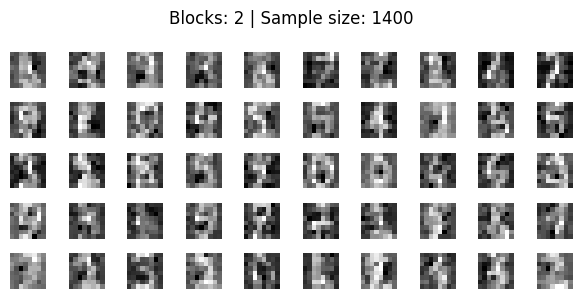

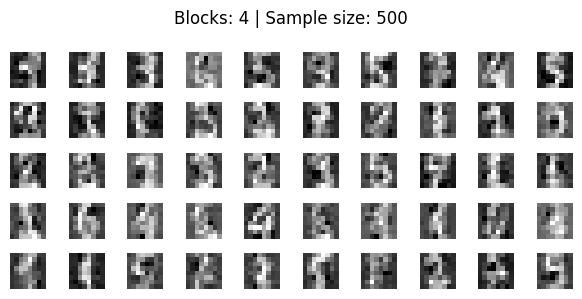

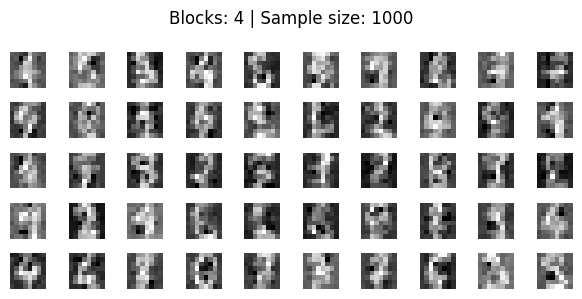

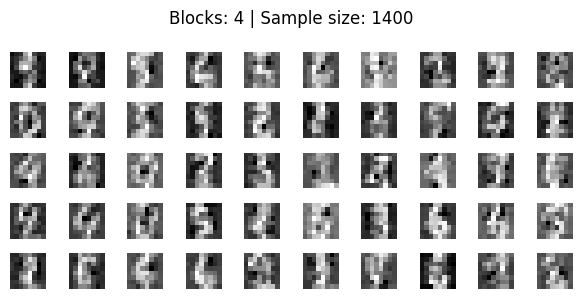

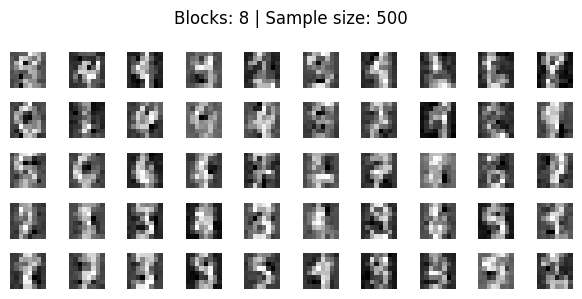

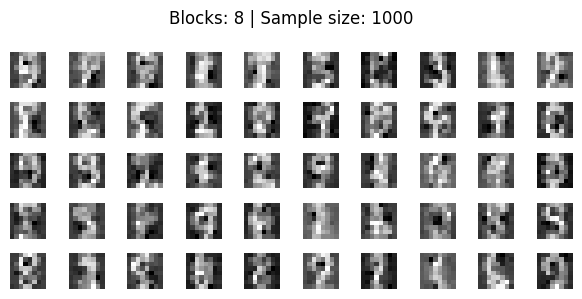

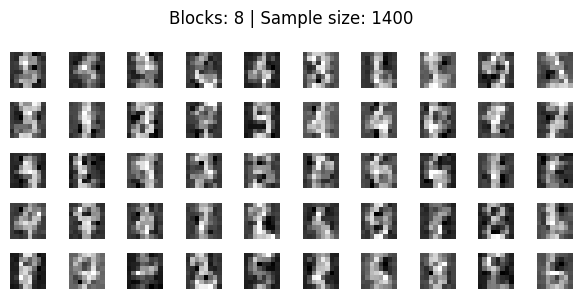

In [33]:
#hyperparameters
blocks = [2, 4, 8]
epochs = 60
n_samples = [500, 1000, 1400]

for b in blocks:
    model_hp = train_inn(X=t, hidden_size=512, blocks=b, batch_size=128, lr=1e-3, epochs=epochs, verbose=False)
    for sample_count in n_samples:
        with torch.no_grad():
            samples = model_hp.sample(sample_count).cpu().numpy()

        fig, axes = plt.subplots(5, 10, figsize=(6, 3))

        for idx, ax in enumerate(axes.flatten()):
            ax.imshow(samples[idx].reshape(8, 8), cmap='gray')
            ax.axis('off')

        plt.suptitle(f"Blocks: {b} | Sample size: {sample_count}")
        plt.tight_layout()
        plt.show() 


In [3]:
#2 bottleneck
def train_bottleneck(X, hidden_size, blocks, batch_size, lr, epochs, k, lambda_rec, device = device, verbose = True):
    X = torch.tensor(X, dtype = torch.float32).to(device)
    dataloader = DataLoader(TensorDataset(X), batch_size = batch_size, shuffle = True)
    
    input_size = X.shape[1]
    model= realNVP(input_size = input_size, hidden_size = hidden_size, blocks = blocks).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)
    
    for e in range(epochs):
        for (batch,) in dataloader:
            z, log_det = model(batch)
            nll_loss = NLL_loss(z, log_det)
            z_rec = z.detach().clone()
            z_rec[:, k:] = 0
            
            x_rec,_ = model.inverse(z_rec)
            loss_rec = torch.mean((x_rec-batch)**2)
            loss = nll_loss + lambda_rec * loss_rec

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        if verbose:
            print(f"Epoch{e+1}/{epochs} \n Negative Log-likelihood: {nll_loss.item():4f}, Reconstruction Loss: {loss_rec.item():.4f}")
    
    return model
    
k = 8
lambda_rec = 50.0
model_bottleneck = train_bottleneck(X_train, hidden_size, blocks, batch_size, lr, epochs, k, lambda_rec, device = device)


Epoch1/60 
 Negative Log-likelihood: 68.168152, Reconstruction Loss: 0.4531
Epoch2/60 
 Negative Log-likelihood: 59.746731, Reconstruction Loss: 0.4405
Epoch3/60 
 Negative Log-likelihood: 56.980377, Reconstruction Loss: 0.4290
Epoch4/60 
 Negative Log-likelihood: 53.633595, Reconstruction Loss: 0.3486
Epoch5/60 
 Negative Log-likelihood: 49.749298, Reconstruction Loss: 0.4145
Epoch6/60 
 Negative Log-likelihood: 49.078140, Reconstruction Loss: 0.2923
Epoch7/60 
 Negative Log-likelihood: 47.495140, Reconstruction Loss: 0.2560
Epoch8/60 
 Negative Log-likelihood: 48.003201, Reconstruction Loss: 0.3535
Epoch9/60 
 Negative Log-likelihood: 48.793953, Reconstruction Loss: 0.3377
Epoch10/60 
 Negative Log-likelihood: 45.736351, Reconstruction Loss: 0.3078
Epoch11/60 
 Negative Log-likelihood: 44.478794, Reconstruction Loss: 0.2866
Epoch12/60 
 Negative Log-likelihood: 45.906219, Reconstruction Loss: 0.3360
Epoch13/60 
 Negative Log-likelihood: 42.802406, Reconstruction Loss: 0.3057
Epoch14/

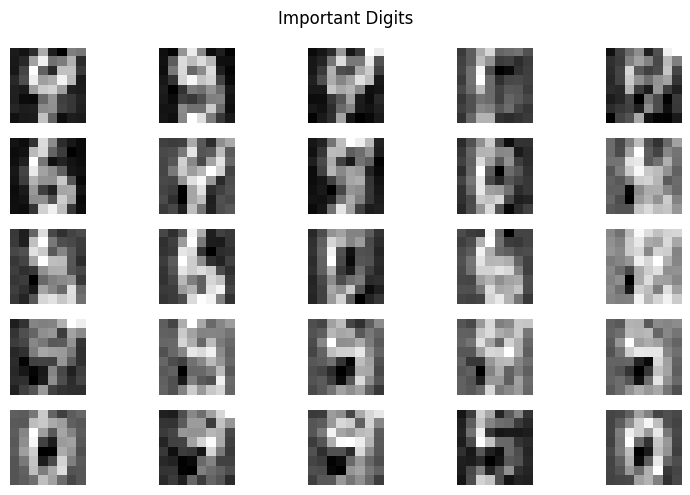

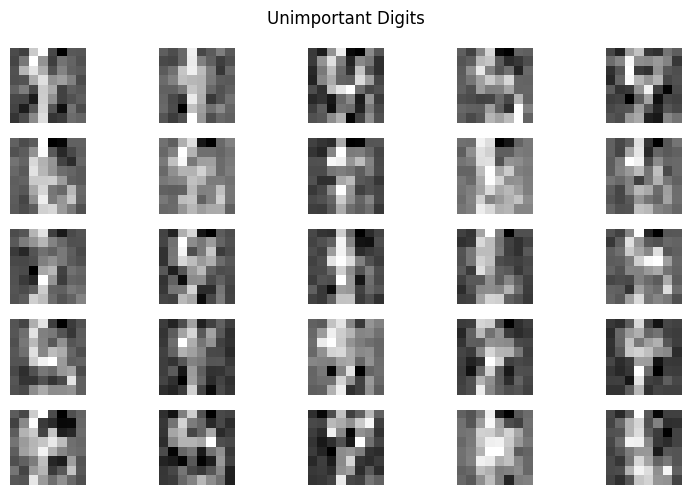

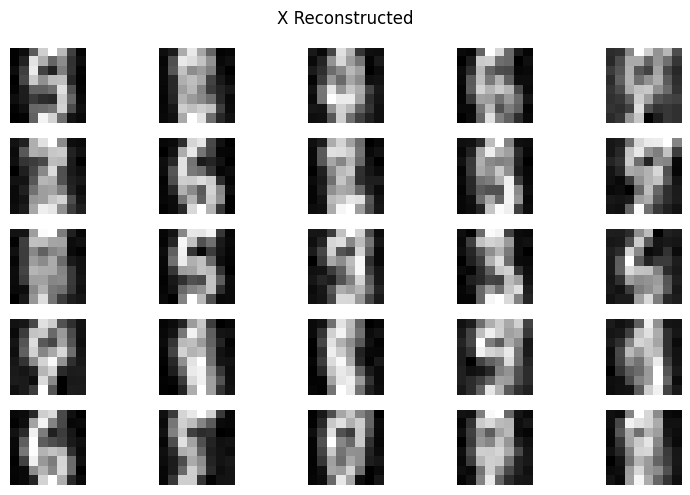

In [4]:
#Visualizations

def sample_important(model, n_samples, k):
    input_dim = model.layers[0].mask.numel()
    z = torch.zeros(n_samples, input_dim).to(device)
    z[:, :k] = torch.randn(n_samples, k)
    x, _ = model.inverse(z)
    return x.cpu().detach().numpy()

def sample_unimportant(model, fixed, n_samples, k):
    input_dim = model.layers[0].mask.numel()
    z = torch.randn(n_samples, input_dim).to(device)
    z[:,:k] = fixed
    x,_ = model.inverse(z)
    return x.cpu().detach().numpy()

def show_digits(X,n_cols = 5, title = None):
    n = X.shape[0]
    n_rows = (n+n_cols-1)//n_cols
    plt.figure(figsize=(8,5))
    for i in range(n):
        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(X[i].reshape(8,8), cmap = 'gray')
        plt.suptitle(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

with torch.no_grad():
    X_test_torch = torch.tensor(X_test, dtype = torch.float32).to(device)
    z_test, _ = model_bottleneck(X_test_torch)

    z_rec = z_test.clone()
    z_rec[:,8:] = 0
    x_recon, _ = model_bottleneck.inverse(z_rec)

n_samples = 50

important= sample_important(model_bottleneck, n_samples = 25, k = 8)
show_digits(important, title = "Important Digits")


fixed_code = torch.randn(1,8)
unimportant = sample_unimportant(model_bottleneck, fixed_code, n_samples = 25, k = 8)
show_digits(unimportant, title = "Unimportant Digits")

X_test_tensor = torch.tensor(X_test, dtype = torch.float32).to(device)
z_test,_ = model_bottleneck(X_test_tensor)
z_test_rec = z_test.clone()
z_test_rec[:,8:] = 0

x_recon,_ = model_bottleneck.inverse(z_test_rec)
show_digits(x_recon.cpu().detach().numpy()[:25], title = "X Reconstructed")

Yes, the quality of the synthetic digits improves by a lot. It is easier to see the general shape of the numbers compared to the uninportant and important digits. 

In [5]:
#3
import torch
from torchvision import datasets , transforms
from torch . utils . data import DataLoader
from PIL import Image , ImageFilter # install 'pillow ' to get PIL
import matplotlib . pyplot as plt
# define a functor to downsample images
class DownsampleTransform :
    def __init__ (self , target_shape , algorithm = Image . Resampling . LANCZOS ):
        self .width , self . height = target_shape
        self . algorithm = algorithm
    def __call__ (self , img ):
        img = img. resize (( self . width +2 , self . height +2) , self . algorithm )
        img = img. crop ((1 , 1 , self . width +1 , self . height +1) )
        return img
# concatenate a few transforms
transform = transforms . Compose ([
DownsampleTransform ( target_shape =(8 ,8) ) ,
transforms . Grayscale ( num_output_channels =1) ,
transforms . ToTensor ()
])
# download MNIST
mnist_dataset = datasets . MNIST ( root ="data", train =True ,
transform = transform , download = True )
# create a DataLoader that serves minibatches of size 100
data_loader = DataLoader ( mnist_dataset , batch_size =100 , shuffle = True )
# visualize the first batch of downsampled MNIST images
def show_first_batch ( data_loader ) :
    for batch in data_loader :
        x, y = batch
        fig = plt. figure ( figsize =(10 , 10) )
        for i, img in enumerate (x):
            ax = fig . add_subplot (10 , 10 , i +1)
            ax. imshow ( img . reshape (8 , 8) , cmap ='gray ')
            ax. axis ('off ')
        break

In [7]:
def mnist_flatten(mnist_dataset):
    X_list = []
    Y_list = []
    for x, y in mnist_dataset:
        X_list.append(x.view(-1).numpy())
        Y_list.append(y)
    return np.array(X_list, dtype = np.float32), np.array(Y_list)

X_mnist, y_mnist = mnist_flatten(mnist_dataset)


model_mnist = train_bottleneck(X_mnist, hidden_size, blocks, batch_size, lr, epochs = 20, k = 32, lambda_rec = 50.0, device = device)
important2 = sample_important(model_mnist, n_samples=50, k=8)

def encode_batches(model, X, batch_size):
    Y = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            y,_ = model(torch.tensor(X[i:i+batch_size], dtype = torch.float32).to(device))
            Y.append(y.cpu())
    return torch.cat(Y, dim = 0)

def decod_batches(model, Y, batch_size):
    X = []
    with torch.no_grad():
        for i in range(0, len(Y), batch_size):
            x,_ = model.inverse(Y[i:i+batch_size].to(device))
            X.append(x.cpu())
    return torch.cat(X, dim = 0)

batch_size = 128
k = 8
all_data = encode_batches(model_mnist, X_mnist, batch_size)

X_mnist_tensor = torch.tensor(X_mnist, dtype = torch.float32).to(device)
all_data, _ = model_mnist(X_mnist_tensor)

z_k = all_data.clone()
z_k[:, k:] = 0

x_rec, _ = model_mnist.inverse(z_k)

Epoch1/20 
 Negative Log-likelihood: 34.472660, Reconstruction Loss: 0.0159
Epoch2/20 
 Negative Log-likelihood: 34.073616, Reconstruction Loss: 0.0158
Epoch3/20 
 Negative Log-likelihood: 33.846584, Reconstruction Loss: 0.0128
Epoch4/20 
 Negative Log-likelihood: 33.939644, Reconstruction Loss: 0.0143
Epoch5/20 
 Negative Log-likelihood: 33.938496, Reconstruction Loss: 0.0151
Epoch6/20 
 Negative Log-likelihood: 33.823277, Reconstruction Loss: 0.0138
Epoch7/20 
 Negative Log-likelihood: 33.796352, Reconstruction Loss: 0.0139
Epoch8/20 
 Negative Log-likelihood: 33.771503, Reconstruction Loss: 0.0126
Epoch9/20 
 Negative Log-likelihood: 33.786201, Reconstruction Loss: 0.0128
Epoch10/20 
 Negative Log-likelihood: 33.695171, Reconstruction Loss: 0.0107
Epoch11/20 
 Negative Log-likelihood: 33.672165, Reconstruction Loss: 0.0112
Epoch12/20 
 Negative Log-likelihood: 33.788357, Reconstruction Loss: 0.0123
Epoch13/20 
 Negative Log-likelihood: 33.754601, Reconstruction Loss: 0.0131
Epoch14/

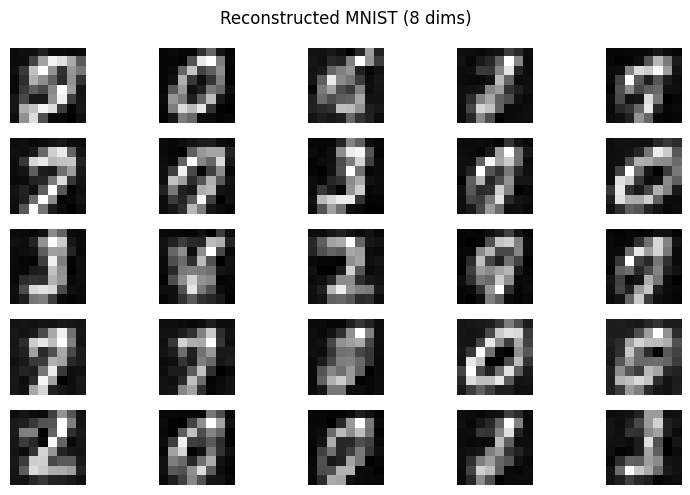

In [9]:
#Visualizaton
show_digits(x_rec.cpu().detach().numpy()[:25], title = f"Reconstructed MNIST ({k} dims)")

